<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/piuminda/resnet_final_last_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Cell 1 — Mount Google Drive and install kaggle
from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from google.colab import files
import os

# Upload your kaggle.json file
print("Please upload your kaggle.json file:")
files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"enjoyfree","key":"ec656a13e6ce47db21def0ce4e767599"}'}

In [10]:
# Setup Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API setup complete!")


✅ Kaggle API setup complete!


In [11]:
import os

# Create directory for dataset
dataset_dir = "/content/drive/MyDrive/DLassignment/assignment"
os.makedirs(dataset_dir, exist_ok=True)

In [12]:
!kaggle datasets download -d techsash/waste-classification-data -p "{dataset_dir}"

print("✅ Dataset download complete!")

Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data
License(s): CC-BY-SA-4.0
 99% 422M/427M [00:02<00:00, 165MB/s]
100% 427M/427M [00:02<00:00, 188MB/s]
✅ Dataset download complete!


In [13]:
# Cell 4 — Extract the dataset
import zipfile
import os

zip_path = "/content/drive/MyDrive/DLassignment/assignment/waste-classification-data.zip"
extract_path = "/content/drive/MyDrive/DLassignment/assignment/waste-classification-data"

# Check if zip file exists before extracting
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully to:", extract_path)
else:
    print("❌ File not found at:", zip_path)

✅ Dataset extracted successfully to: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data


In [14]:
# Cell 5 — Verify dataset structure
import os

dataset_path = "/content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET"

train_path = os.path.join(dataset_path, "TRAIN")
test_path = os.path.join(dataset_path, "TEST")

# Verify paths
print("TRAIN path exists:", os.path.exists(train_path))
print("TEST path exists:", os.path.exists(test_path))


TRAIN path exists: True
TEST path exists: True


In [15]:
# Check what classes are available
if os.path.exists(train_path):
    train_classes = os.listdir(train_path)
    print("Training classes:", train_classes)

if os.path.exists(test_path):
    test_classes = os.listdir(test_path)
    print("Testing classes:", test_classes)

print("\n✅ Dataset verification complete!")

Training classes: ['O', 'R']
Testing classes: ['O', 'R']

✅ Dataset verification complete!


📊 DATASET SAMPLE VISUALIZATION
🖼️  Sample Images from TRAIN Dataset:


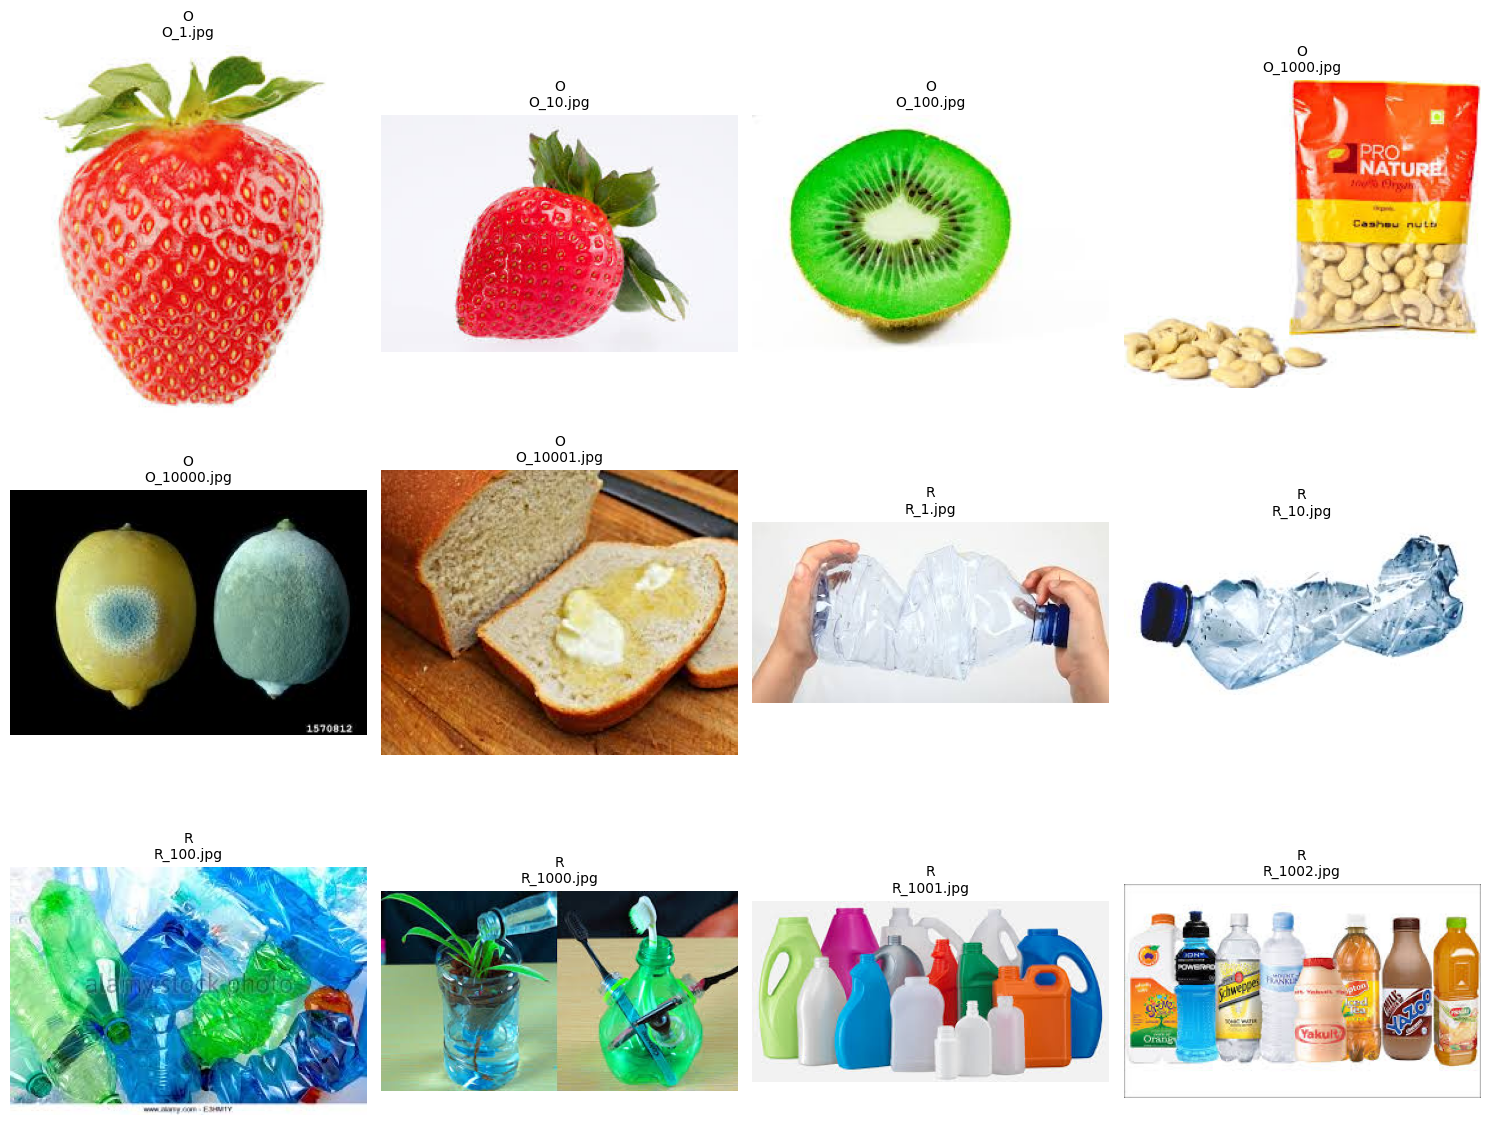


🖼️  Sample Images from TEST Dataset:


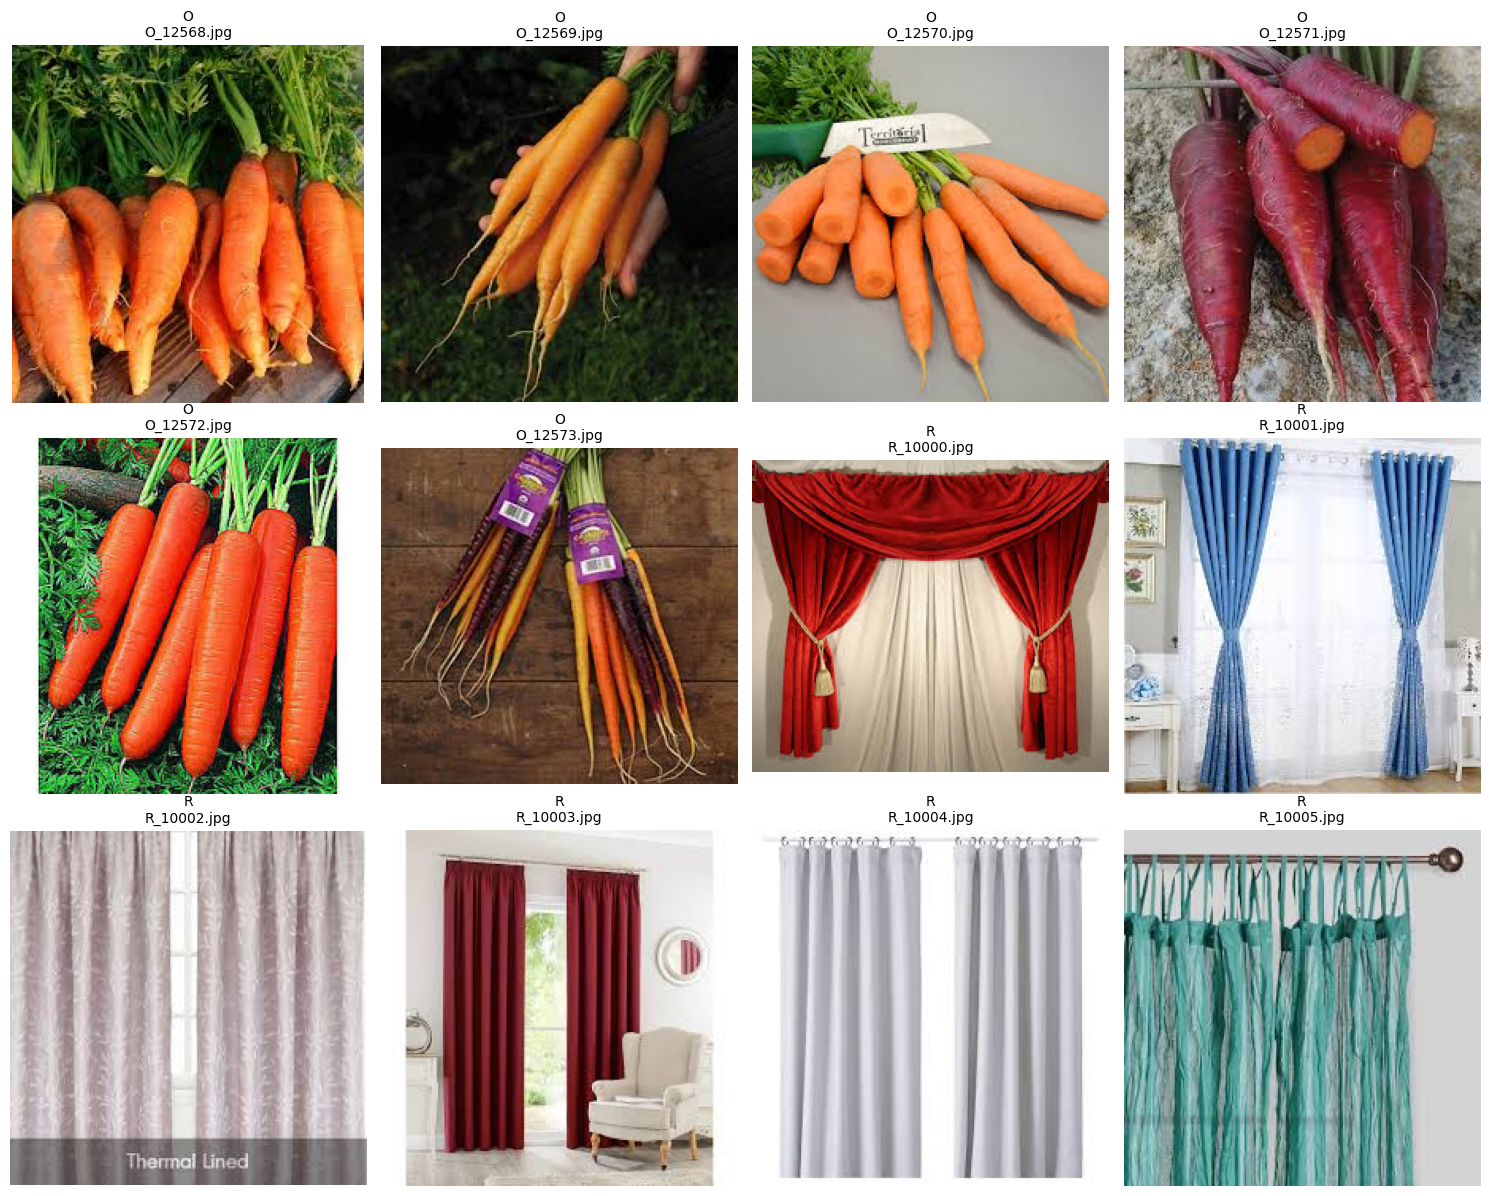

In [63]:
# Cell 5a — Dataset Sample Visualization
print("📊 DATASET SAMPLE VISUALIZATION")
print("="*50)

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def show_dataset_samples(dataset_path, num_samples=12):
    """Display sample images from the dataset"""
    dataset_path = Path(dataset_path)

    # Get all class folders
    class_folders = [f for f in dataset_path.iterdir() if f.is_dir()]

    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.ravel()

    sample_count = 0
    for class_folder in class_folders:
        class_name = class_folder.name
        # Get some images from this class
        image_files = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.jpeg")) + list(class_folder.glob("*.png"))

        if not image_files:
            continue

        # Take up to 6 samples per class
        for img_path in image_files[:6]:
            if sample_count >= num_samples:
                break

            try:
                # Load and display image
                img = plt.imread(img_path)
                axes[sample_count].imshow(img)
                axes[sample_count].set_title(f"{class_name}\n{img_path.name}", fontsize=10)
                axes[sample_count].axis('off')
                sample_count += 1
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue

        if sample_count >= num_samples:
            break

    # Hide unused subplots
    for i in range(sample_count, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Show samples from TRAIN directory
print("🖼️  Sample Images from TRAIN Dataset:")
show_dataset_samples(TRAIN_DIR)

# Show samples from TEST directory
print("\n🖼️  Sample Images from TEST Dataset:")
show_dataset_samples(TEST_DIR)

In [64]:
# Cell 5b — Dataset Statistics and Analysis
print("📈 DATASET STATISTICS AND ANALYSIS")
print("="*50)

def analyze_dataset(dataset_path):
    """Analyze dataset statistics"""
    dataset_path = Path(dataset_path)

    stats = {}
    total_images = 0

    print(f"Analyzing: {dataset_path}")

    for class_folder in dataset_path.iterdir():
        if class_folder.is_dir():
            class_name = class_folder.name
            image_files = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.jpeg")) + list(class_folder.glob("*.png"))
            image_count = len(image_files)
            stats[class_name] = image_count
            total_images += image_count

            print(f"  {class_name}: {image_count} images")

            # Show image dimensions for first few images
            if image_files:
                sample_sizes = []
                for img_path in image_files[:5]:  # Check first 5 images
                    try:
                        img = plt.imread(img_path)
                        sample_sizes.append(img.shape)
                    except:
                        continue
                if sample_sizes:
                    unique_sizes = set(sample_sizes)
                    print(f"    Sample dimensions: {list(unique_sizes)[:3]}")  # Show up to 3 unique sizes

    print(f"Total images: {total_images}")
    return stats, total_images

print("TRAIN Dataset Analysis:")
train_stats, train_total = analyze_dataset(TRAIN_DIR)

print("\nTEST Dataset Analysis:")
test_stats, test_total = analyze_dataset(TEST_DIR)

# Calculate and display percentages
print(f"\n📊 Dataset Split Summary:")
print(f"Training set: {train_total} images ({train_total/(train_total+test_total)*100:.1f}%)")
print(f"Test set: {test_total} images ({test_total/(train_total+test_total)*100:.1f}%)")
print(f"Total dataset: {train_total + test_total} images")

📈 DATASET STATISTICS AND ANALYSIS
TRAIN Dataset Analysis:
Analyzing: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET/TRAIN
  O: 12565 images
    Sample dimensions: [(186, 271, 3), (183, 275, 3), (209, 242, 3)]
  R: 9999 images
    Sample dimensions: [(168, 300, 3), (187, 269, 3), (160, 314, 3)]
Total images: 22564

TEST Dataset Analysis:
Analyzing: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET/TEST
  O: 1401 images
    Sample dimensions: [(225, 225, 3), (227, 223, 3)]
  R: 1112 images
    Sample dimensions: [(210, 240, 3), (224, 225, 3), (225, 225, 3)]
Total images: 2513

📊 Dataset Split Summary:
Training set: 22564 images (90.0%)
Test set: 2513 images (10.0%)
Total dataset: 25077 images


In [16]:
# Cell 6 — Import all required libraries
import os, shutil, random, itertools, math, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import itertools
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support
from sklearn.utils import class_weight

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("✅ All libraries imported successfully!")



✅ All libraries imported successfully!


In [17]:
# Cell 7 — Configure paths and parameters for Google Drive
DATA_ROOT = Path("/content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET")
TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR = DATA_ROOT / "TEST"

# Create output directory in Google Drive
OUTPUT_DIR = Path("/content/drive/MyDrive/DLassignment/assignment/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Image and training parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

print("📁 Path Configuration:")
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)
print("Output directory:", OUTPUT_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())
print("Output exists:", OUTPUT_DIR.exists())


📁 Path Configuration:
Train directory: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET/TRAIN
Test directory: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET/TEST
Output directory: /content/drive/MyDrive/DLassignment/assignment/output
Train exists: True
Test exists: True
Output exists: True


📏 IMAGE SIZE ANALYSIS
Training set image size analysis:
Analyzed 200 sample images
Unique dimensions found: 77
Most common dimension: [183 275   3] (32 images, 16.0%)
Height range: 123 - 282 pixels
Width range: 150 - 410 pixels
Channels: {np.int64(3), np.int64(4)}


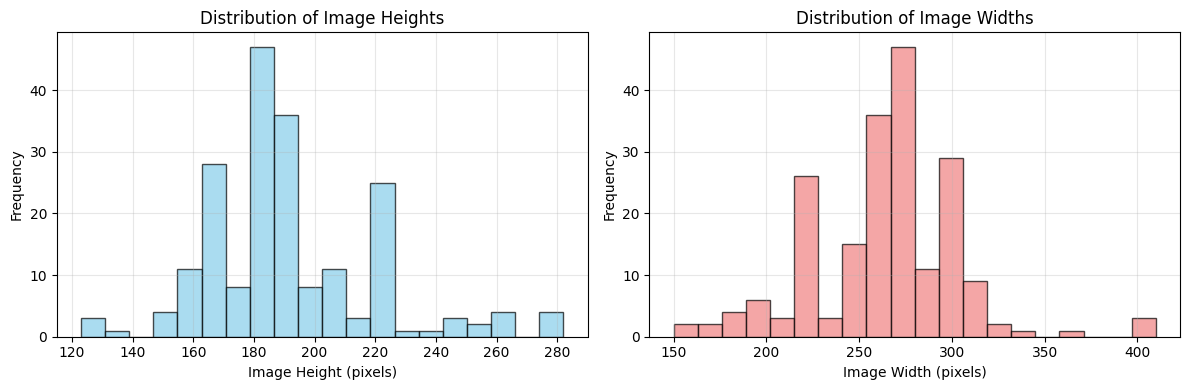


Test set image size analysis:
Analyzed 200 sample images
Unique dimensions found: 60
Most common dimension: [225 225   3] (101 images, 50.5%)
Height range: 145 - 285 pixels
Width range: 177 - 348 pixels
Channels: {np.int64(3)}


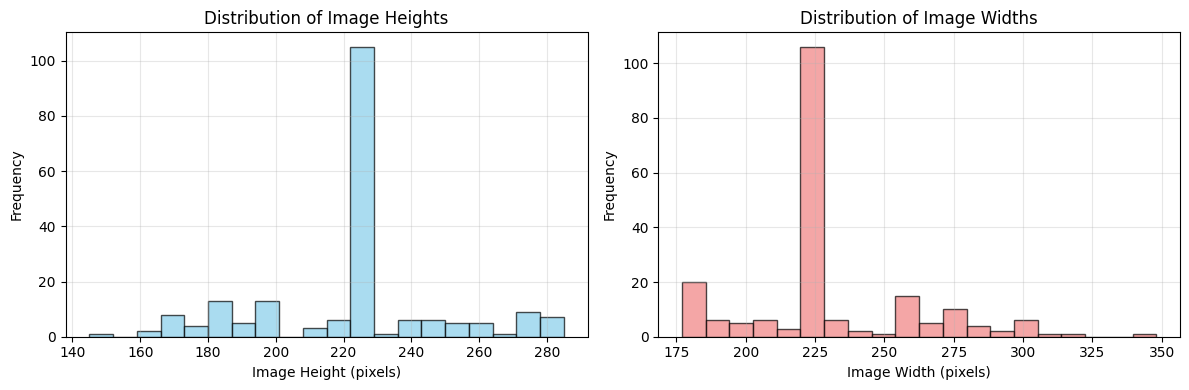

In [65]:
# Cell 5d — Image Size Analysis
print("📏 IMAGE SIZE ANALYSIS")
print("="*50)

def analyze_image_sizes(dataset_path, sample_size=100):
    """Analyze image dimensions in the dataset"""
    dataset_path = Path(dataset_path)

    dimensions = []
    total_images = 0

    for class_folder in dataset_path.iterdir():
        if class_folder.is_dir():
            image_files = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.jpeg")) + list(class_folder.glob("*.png"))

            for img_path in image_files[:sample_size]:  # Sample to avoid processing all
                try:
                    img = plt.imread(img_path)
                    dimensions.append(img.shape)
                    total_images += 1
                except Exception as e:
                    continue

    if dimensions:
        # Convert to numpy array for easier analysis
        dim_array = np.array(dimensions)

        print(f"Analyzed {total_images} sample images")
        print(f"Unique dimensions found: {len(set(dimensions))}")

        # Most common dimensions
        unique, counts = np.unique(dim_array, axis=0, return_counts=True)
        most_common_idx = np.argmax(counts)
        most_common = unique[most_common_idx]
        most_common_count = counts[most_common_idx]

        print(f"Most common dimension: {most_common} ({most_common_count} images, {most_common_count/total_images*100:.1f}%)")

        # Dimension statistics
        heights = dim_array[:, 0]
        widths = dim_array[:, 1]
        channels = dim_array[:, 2] if dim_array.shape[1] > 2 else [3] * len(dim_array)

        print(f"Height range: {heights.min()} - {heights.max()} pixels")
        print(f"Width range: {widths.min()} - {widths.max()} pixels")
        print(f"Channels: {set(channels)}")

        # Plot dimension distribution
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.hist(heights, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.xlabel('Image Height (pixels)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Image Heights')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.hist(widths, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
        plt.xlabel('Image Width (pixels)')
        plt.ylabel('Frequency')
        plt.title('Distribution of Image Widths')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    else:
        print("No images found or could not read image dimensions")

print("Training set image size analysis:")
analyze_image_sizes(TRAIN_DIR)

print("\nTest set image size analysis:")
analyze_image_sizes(TEST_DIR)

In [66]:
# Cell 5e — Dataset Quality Check
print("🔍 DATASET QUALITY CHECK")
print("="*50)

def check_dataset_quality(dataset_path):
    """Check for common dataset issues"""
    dataset_path = Path(dataset_path)

    issues = []
    total_images = 0
    corrupt_images = 0

    print(f"Checking dataset quality for: {dataset_path}")

    for class_folder in dataset_path.iterdir():
        if class_folder.is_dir():
            class_name = class_folder.name
            image_files = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.jpeg")) + list(class_folder.glob("*.png"))

            if not image_files:
                issues.append(f"❌ Class '{class_name}': No images found")
                continue

            print(f"  Checking {class_name} ({len(image_files)} images)...")

            # Check for corrupt images
            for img_path in image_files[:50]:  # Check first 50 images per class
                total_images += 1
                try:
                    img = plt.imread(img_path)
                    # Basic checks
                    if img.size == 0:
                        corrupt_images += 1
                        issues.append(f"❌ Empty image: {img_path.name}")
                    elif len(img.shape) not in [2, 3]:
                        corrupt_images += 1
                        issues.append(f"❌ Invalid dimensions: {img_path.name} - shape {img.shape}")
                except Exception as e:
                    corrupt_images += 1
                    issues.append(f"❌ Corrupt image: {img_path.name} - {str(e)}")

    # Summary
    print(f"\n📋 Quality Check Summary:")
    print(f"Total images checked: {total_images}")
    print(f"Corrupt/issue images: {corrupt_images}")
    print(f"Quality score: {(total_images - corrupt_images)/total_images*100:.1f}%")

    if issues:
        print(f"\n⚠️  Issues found ({len(issues)}):")
        for issue in issues[:10]:  # Show first 10 issues
            print(f"  {issue}")
        if len(issues) > 10:
            print(f"  ... and {len(issues) - 10} more issues")
    else:
        print("✅ No issues found - dataset looks good!")

    return issues

print("Training set quality check:")
train_issues = check_dataset_quality(TRAIN_DIR)

print("\nTest set quality check:")
test_issues = check_dataset_quality(TEST_DIR)

🔍 DATASET QUALITY CHECK
Training set quality check:
Checking dataset quality for: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET/TRAIN
  Checking O (12565 images)...
  Checking R (9999 images)...

📋 Quality Check Summary:
Total images checked: 100
Corrupt/issue images: 0
Quality score: 100.0%
✅ No issues found - dataset looks good!

Test set quality check:
Checking dataset quality for: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET/TEST
  Checking O (1401 images)...
  Checking R (1112 images)...

📋 Quality Check Summary:
Total images checked: 100
Corrupt/issue images: 0
Quality score: 100.0%
✅ No issues found - dataset looks good!


In [67]:
# Cell 5f — Dataset Summary Report
print("📄 DATASET SUMMARY REPORT")
print("="*50)

def generate_dataset_report():
    """Generate comprehensive dataset report"""

    print("🎯 WASTE CLASSIFICATION DATASET REPORT")
    print("="*40)

    # Basic information
    print(f"\n📁 Dataset Location: {DATA_ROOT}")
    print(f"📊 Total Images: {train_total + test_total}")
    print(f"🎯 Classes: {list(CLASS_MAPPING.values())}")
    print(f"📐 Target Image Size: {IMG_SIZE}")

    # Training set info
    print(f"\n🏋️ TRAINING SET:")
    print(f"  Images: {train_total}")
    for cls, count in train_stats.items():
        mapped_name = CLASS_MAPPING.get(cls, cls)
        percentage = (count / train_total) * 100
        print(f"  {mapped_name}: {count} images ({percentage:.1f}%)")

    # Test set info
    print(f"\n🧪 TEST SET:")
    print(f"  Images: {test_total}")
    for cls, count in test_stats.items():
        mapped_name = CLASS_MAPPING.get(cls, cls)
        percentage = (count / test_total) * 100
        print(f"  {mapped_name}: {count} images ({percentage:.1f}%)")

    # Class balance analysis
    print(f"\n⚖️ CLASS BALANCE ANALYSIS:")
    for cls in train_stats.keys():
        mapped_name = CLASS_MAPPING.get(cls, cls)
        train_count = train_stats[cls]
        test_count = test_stats.get(cls, 0)
        train_ratio = train_count / train_total
        test_ratio = test_count / test_total if test_total > 0 else 0

        balance_status = "✅ Balanced" if abs(train_ratio - test_ratio) < 0.1 else "⚠️ Imbalanced"
        print(f"  {mapped_name}: Train {train_ratio:.1%} vs Test {test_ratio:.1%} - {balance_status}")

    # Data split analysis
    print(f"\n📈 DATA SPLIT ANALYSIS:")
    split_ratio = test_total / (train_total + test_total)
    print(f"  Train/Test split: {1-split_ratio:.1%}/{split_ratio:.1%}")

    if split_ratio < 0.15:
        print("  ⚠️  Test set might be too small for reliable evaluation")
    elif split_ratio > 0.35:
        print("  ⚠️  Training set might be too small for good model training")
    else:
        print("  ✅ Good train/test split ratio")

    # Final recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    if any(len(issues) > 0 for issues in [train_issues, test_issues]):
        print("  1. Address image quality issues before training")
    if any(abs(train_stats[cls]/train_total - test_stats.get(cls, 0)/test_total) > 0.1 for cls in train_stats.keys()):
        print("  2. Consider balancing class distribution between train and test sets")
    print("  3. Ensure proper data augmentation for robust model training")
    print("  4. Monitor class weights during training to handle imbalance")

# Generate the comprehensive report
generate_dataset_report()

📄 DATASET SUMMARY REPORT
🎯 WASTE CLASSIFICATION DATASET REPORT

📁 Dataset Location: /content/drive/MyDrive/DLassignment/assignment/waste-classification-data/DATASET
📊 Total Images: 25077
🎯 Classes: ['organic', 'recycle']
📐 Target Image Size: (224, 224)

🏋️ TRAINING SET:
  Images: 22564
  organic: 12565 images (55.7%)
  recycle: 9999 images (44.3%)

🧪 TEST SET:
  Images: 2513
  organic: 1401 images (55.8%)
  recycle: 1112 images (44.2%)

⚖️ CLASS BALANCE ANALYSIS:
  organic: Train 55.7% vs Test 55.8% - ✅ Balanced
  recycle: Train 44.3% vs Test 44.2% - ✅ Balanced

📈 DATA SPLIT ANALYSIS:
  Train/Test split: 90.0%/10.0%
  ⚠️  Test set might be too small for reliable evaluation

💡 RECOMMENDATIONS:
  3. Ensure proper data augmentation for robust model training
  4. Monitor class weights during training to handle imbalance


In [18]:
# Cell 8 — Define class mapping for binary classification
CLASS_MAPPING = {
    'O': 'organic',      # Organic waste
    'R': 'recycle'       # Recyclable waste
}

print("🗂️ Class Mapping:")
for orig_class, binary_label in CLASS_MAPPING.items():
    print(f"  {orig_class} → {binary_label}")

# Verify the classes exist in dataset
if TRAIN_DIR.exists():
    actual_classes = [p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]
    print("\n📊 Actual classes found in dataset:", actual_classes)

    # Check if all classes are mapped
    for cls in actual_classes:
        if cls not in CLASS_MAPPING:
            print(f"⚠️ Warning: Class '{cls}' not mapped in CLASS_MAPPING!")


🗂️ Class Mapping:
  O → organic
  R → recycle

📊 Actual classes found in dataset: ['O', 'R']


In [19]:
# Cell 9 — Create binary dataset structure
def build_binary_dataset(source_root, dest_root, class_map):
    """
    source_root: Path containing subfolders (each class)
    dest_root: Path to create binary folders inside (dest_root/train, dest_root/val, dest_root/test)
    class_map: dict mapping original class names -> 'organic' or 'recycle'
    """
    source_root = Path(source_root)
    dest_root = Path(dest_root)

    # Create directory structure
    for split in ["train", "val", "test"]:
        (dest_root / split / "organic").mkdir(parents=True, exist_ok=True)
        (dest_root / split / "recycle").mkdir(parents=True, exist_ok=True)

    # Process TRAIN data (split into train/val)
    train_pairs = []
    for orig_class in (source_root / "TRAIN").iterdir():
        if not orig_class.is_dir():
            continue
        label = class_map.get(orig_class.name)
        if label is None:
            print(f"Skipping unmapped class: {orig_class.name}")
            continue
        for f in orig_class.iterdir():
            if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                train_pairs.append((f, label))

    # Shuffle and split train into train/val (80/20)
    random.shuffle(train_pairs)
    n_train = int(0.8 * len(train_pairs))

    print(f"📊 Splitting {len(train_pairs)} training images:")
    print(f"  - Train: {n_train} images")
    print(f"  - Validation: {len(train_pairs) - n_train} images")

    for i, (f, label) in enumerate(train_pairs):
        if i < n_train:
            split = "train"
        else:
            split = "val"
        dest = dest_root / split / label
        shutil.copy(f, dest / f.name)

    # Process TEST data
    test_count = 0
    for orig_class in (source_root / "TEST").iterdir():
        if not orig_class.is_dir():
            continue
        label = class_map.get(orig_class.name)
        if label is None:
            continue
        for f in orig_class.iterdir():
            if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                dest = dest_root / "test" / label
                shutil.copy(f, dest / f.name)
                test_count += 1

    print(f"  - Test: {test_count} images")
    print(f"✅ Binary dataset created at {dest_root}")

# Create binary dataset
BINARY_ROOT = Path("/content/drive/MyDrive/DLassignment/assignment/data_binary")
build_binary_dataset(DATA_ROOT, BINARY_ROOT, CLASS_MAPPING)

📊 Splitting 22564 training images:
  - Train: 18051 images
  - Validation: 4513 images
  - Test: 2513 images
✅ Binary dataset created at /content/drive/MyDrive/DLassignment/assignment/data_binary


In [20]:
# Cell 10 — Verify binary dataset structure
TRAIN_BIN = BINARY_ROOT / "train"
VAL_BIN = BINARY_ROOT / "val"
TEST_BIN = BINARY_ROOT / "test"

print("📁 Binary Dataset Structure:")
print(f"Train: {TRAIN_BIN} - exists: {TRAIN_BIN.exists()}")
print(f"Val: {VAL_BIN} - exists: {VAL_BIN.exists()}")
print(f"Test: {TEST_BIN} - exists: {TEST_BIN.exists()}")

# Count images in each split
print("\n📊 Image Counts:")
for split_name, split_path in [("Train", TRAIN_BIN), ("Val", VAL_BIN), ("Test", TEST_BIN)]:
    if split_path.exists():
        organic_count = len(list((split_path / "organic").glob("*.*")))
        recycle_count = len(list((split_path / "recycle").glob("*.*")))
        total = organic_count + recycle_count
        print(f"  {split_name}: Organic={organic_count}, Recycle={recycle_count}, Total={total}")

📁 Binary Dataset Structure:
Train: /content/drive/MyDrive/DLassignment/assignment/data_binary/train - exists: True
Val: /content/drive/MyDrive/DLassignment/assignment/data_binary/val - exists: True
Test: /content/drive/MyDrive/DLassignment/assignment/data_binary/test - exists: True

📊 Image Counts:
  Train: Organic=10067, Recycle=7984, Total=18051
  Val: Organic=2498, Recycle=2015, Total=4513
  Test: Organic=1401, Recycle=1112, Total=2513


In [21]:
# Cell 11 — Create ImageDataGenerators with ENHANCED data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=30,  # Increased from 20
    width_shift_range=0.2,  # Increased from 0.1
    height_shift_range=0.2,  # Increased from 0.1
    shear_range=0.2,  # Increased from 0.1
    zoom_range=0.25,  # Increased from 0.15
    horizontal_flip=True,
    vertical_flip=True,  # Added vertical flip
    brightness_range=[0.8, 1.2],  # Added brightness variation
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

# Create data generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_BIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_BIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_BIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=False
)

print("✅ Data generators created successfully!")
print("Class indices:", train_gen.class_indices)


Found 18051 images belonging to 2 classes.
Found 4513 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
✅ Data generators created successfully!
Class indices: {'organic': 0, 'recycle': 1}


In [22]:
# Cell 12 — Compute ENHANCED class weights for better balance
y_train = train_gen.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Enhanced weighting - give more importance to recyclable class
class_weight_dict = {
    0: class_weights[0] * 0.9,  # Slightly reduce organic weight
    1: class_weights[1] * 1.2   # Increase recyclable weight
}

print("⚖️ Enhanced Class weights:", class_weight_dict)

⚖️ Enhanced Class weights: {0: np.float64(0.8068888447402404), 1: np.float64(1.3565380761523047)}


In [23]:
# Cell 13 — Build IMPROVED ResNet50-based model with better regularization
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # Freeze base model initially

# Build IMPROVED classifier head
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)  # Added BatchNorm
x = layers.Dropout(0.5)(x)  # Increased dropout
x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01))(x)  # Added L2 regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

# Compile model with focal loss (better for imbalanced data)
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -keras.backend.mean(alpha * keras.backend.pow(1. - pt_1, gamma) * keras.backend.log(pt_1)) \
               -keras.backend.mean((1-alpha) * keras.backend.pow(pt_0, gamma) * keras.backend.log(1. - pt_0))
    return focal_loss_fixed

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(),  # Using focal loss instead of binary crossentropy
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

print("✅ IMPROVED Model built successfully!")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
✅ IMPROVED Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,154,497 (92.14 MB)

 Trainable params: 562,177 (2.14 MB)

 Non-trainable params: 23,592,320 (90.00 MB)

In [24]:
# Cell 14 — Configure training callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    OUTPUT_DIR / "best_improved_model.h5",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,  # Increased patience
    restore_best_weights=True,
    verbose=1
)

tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir=str(OUTPUT_DIR / "improved_logs")
)

print("✅ Training callbacks configured!")

✅ Training callbacks configured!


In [25]:

# Cell 15 — Train with frozen base model
print("🚀 Starting Phase 1: Training with frozen base model...")

history1 = model.fit(
    train_gen,
    epochs=10,  # Increased epochs
    validation_data=val_gen,
    callbacks=[checkpoint_cb, reduce_lr, early_stop, tensorboard_cb],
    class_weight=class_weight_dict,
    verbose=1
)

print("✅ Phase 1 training completed!")


🚀 Starting Phase 1: Training with frozen base model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.7332 - auc: 0.8044 - loss: 5.4867
Epoch 1: val_auc improved from -inf to 0.97911, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 357s 600ms/step - accuracy: 0.7333 - auc: 0.8045 - loss: 5.4852 - val_accuracy: 0.9160 - val_auc: 0.9791 - val_loss: 3.0773 - learning_rate: 1.0000e-04
Epoch 2/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.8456 - auc: 0.9330 - loss: 2.5783
Epoch 2: val_auc improved from 0.97911 to 0.98565, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 328s 580ms/step - accuracy: 0.8456 - auc: 0.9330 - loss: 2.5775 - val_accuracy: 0.9306 - val_auc: 0.9856 - val_loss: 1.3439 - learning_rate: 1.0000e-04
Epoch 3/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.8746 - auc: 0.9550 - loss: 1.1171
Epoch 3: val_auc improved from 0.98565 to 0.98735, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 330s 584ms/step - accuracy: 0.8746 - auc: 0.9550 - loss: 1.1167 - val_accuracy: 0.9344 - val_auc: 0.9874 - val_loss: 0.5614 - learning_rate: 1.0000e-04
Epoch 4/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.8923 - auc: 0.9661 - loss: 0.4698
Epoch 4: val_auc improved from 0.98735 to 0.98926, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 328s 581ms/step - accuracy: 0.8923 - auc: 0.9662 - loss: 0.4697 - val_accuracy: 0.9417 - val_auc: 0.9893 - val_loss: 0.2357 - learning_rate: 1.0000e-04
Epoch 5/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.9052 - auc: 0.9741 - loss: 0.2034
Epoch 5: val_auc improved from 0.98926 to 0.99048, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 329s 582ms/step - accuracy: 0.9052 - auc: 0.9741 - loss: 0.2034 - val_accuracy: 0.9470 - val_auc: 0.9905 - val_loss: 0.1063 - learning_rate: 1.0000e-04
Epoch 6/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9173 - auc: 0.9782 - loss: 0.0978
Epoch 6: val_auc improved from 0.99048 to 0.99123, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 333s 590ms/step - accuracy: 0.9173 - auc: 0.9782 - loss: 0.0978 - val_accuracy: 0.9377 - val_auc: 0.9912 - val_loss: 0.0578 - learning_rate: 1.0000e-04
Epoch 7/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9121 - auc: 0.9758 - loss: 0.0604
Epoch 7: val_auc did not improve from 0.99123
565/565 ━━━━━━━━━━━━━━━━━━━━ 333s 590ms/step - accuracy: 0.9121 - auc: 0.9758 - loss: 0.0604 - val_accuracy: 0.9455 - val_auc: 0.9898 - val_loss: 0.0400 - learning_rate: 1.0000e-04
Epoch 8/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9160 - auc: 0.9767 - loss: 0.0458
Epoch 8: val_auc did not improve from 0.99123
565/565 ━━━━━━━━━━━━━━━━━━━━ 330s 583ms/step - accuracy: 0.9160 - auc: 0.9767 - loss: 0.0458 - val_accuracy: 0.9439 - val_auc: 0.9899 - val_loss: 0.0347 - learning_rate: 1.0000e-04
Epoch 9/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.9115 - auc: 0.9736 - loss: 0.0425
Epoch 9: val_auc did not improve from 0.99123
565/565 ━━━━━

In [26]:
# Cell 16 — Fine-tune with unfrozen layers
print("🔧 Starting Phase 2: Fine-tuning with unfrozen layers...")

# Unfreeze more layers for better feature learning
base_model.trainable = True
for layer in base_model.layers[:-30]:  # Unfreeze more layers
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(),
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

# Continue training
history2 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[checkpoint_cb, reduce_lr, early_stop, tensorboard_cb],
    class_weight=class_weight_dict,
    verbose=1
)

print("✅ Phase 2 training completed!")

🔧 Starting Phase 2: Fine-tuning with unfrozen layers...
Epoch 1/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9165 - auc: 0.9788 - loss: 0.0630
Epoch 1: val_auc improved from 0.99123 to 0.99266, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 369s 612ms/step - accuracy: 0.9165 - auc: 0.9788 - loss: 0.0630 - val_accuracy: 0.9555 - val_auc: 0.9927 - val_loss: 0.0490 - learning_rate: 1.0000e-05
Epoch 2/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.9292 - auc: 0.9828 - loss: 0.0546
Epoch 2: val_auc improved from 0.99266 to 0.99322, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 327s 577ms/step - accuracy: 0.9292 - auc: 0.9828 - loss: 0.0546 - val_accuracy: 0.9588 - val_auc: 0.9932 - val_loss: 0.0431 - learning_rate: 1.0000e-05
Epoch 3/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9349 - auc: 0.9870 - loss: 0.0475
Epoch 3: val_auc improved from 0.99322 to 0.99363, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 328s 580ms/step - accuracy: 0.9349 - auc: 0.9870 - loss: 0.0475 - val_accuracy: 0.9610 - val_auc: 0.9936 - val_loss: 0.0383 - learning_rate: 1.0000e-05
Epoch 4/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.9390 - auc: 0.9886 - loss: 0.0424
Epoch 4: val_auc improved from 0.99363 to 0.99442, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 381s 579ms/step - accuracy: 0.9390 - auc: 0.9886 - loss: 0.0424 - val_accuracy: 0.9617 - val_auc: 0.9944 - val_loss: 0.0344 - learning_rate: 1.0000e-05
Epoch 5/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.9500 - auc: 0.9911 - loss: 0.0367
Epoch 5: val_auc did not improve from 0.99442
565/565 ━━━━━━━━━━━━━━━━━━━━ 331s 586ms/step - accuracy: 0.9500 - auc: 0.9911 - loss: 0.0367 - val_accuracy: 0.9610 - val_auc: 0.9940 - val_loss: 0.0313 - learning_rate: 1.0000e-05
Epoch 6/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.9524 - auc: 0.9925 - loss: 0.0324
Epoch 6: val_auc improved from 0.99442 to 0.99457, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 376s 575ms/step - accuracy: 0.9524 - auc: 0.9925 - loss: 0.0324 - val_accuracy: 0.9645 - val_auc: 0.9946 - val_loss: 0.0281 - learning_rate: 1.0000e-05
Epoch 7/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.9572 - auc: 0.9931 - loss: 0.0291
Epoch 7: val_auc did not improve from 0.99457
565/565 ━━━━━━━━━━━━━━━━━━━━ 324s 573ms/step - accuracy: 0.9572 - auc: 0.9931 - loss: 0.0291 - val_accuracy: 0.9603 - val_auc: 0.9943 - val_loss: 0.0258 - learning_rate: 1.0000e-05
Epoch 8/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.9593 - auc: 0.9937 - loss: 0.0265
Epoch 8: val_auc did not improve from 0.99457
565/565 ━━━━━━━━━━━━━━━━━━━━ 329s 582ms/step - accuracy: 0.9593 - auc: 0.9937 - loss: 0.0265 - val_accuracy: 0.9619 - val_auc: 0.9943 - val_loss: 0.0243 - learning_rate: 1.0000e-05
Epoch 9/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9620 - auc: 0.9948 - loss: 0.0239
Epoch 9: val_auc did not improve from 0.99457
565/565 ━━━━━

565/565 ━━━━━━━━━━━━━━━━━━━━ 325s 575ms/step - accuracy: 0.9654 - auc: 0.9960 - loss: 0.0197 - val_accuracy: 0.9659 - val_auc: 0.9947 - val_loss: 0.0204 - learning_rate: 1.0000e-05
Epoch 12/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9726 - auc: 0.9970 - loss: 0.0169
Epoch 12: val_auc did not improve from 0.99473
565/565 ━━━━━━━━━━━━━━━━━━━━ 322s 570ms/step - accuracy: 0.9725 - auc: 0.9970 - loss: 0.0170 - val_accuracy: 0.9648 - val_auc: 0.9942 - val_loss: 0.0208 - learning_rate: 1.0000e-05
Epoch 13/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.9735 - auc: 0.9968 - loss: 0.0163
Epoch 13: val_auc improved from 0.99473 to 0.99477, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 325s 576ms/step - accuracy: 0.9735 - auc: 0.9968 - loss: 0.0163 - val_accuracy: 0.9657 - val_auc: 0.9948 - val_loss: 0.0185 - learning_rate: 1.0000e-05
Epoch 14/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.9744 - auc: 0.9973 - loss: 0.0148
Epoch 14: val_auc improved from 0.99477 to 0.99483, saving model to /content/drive/MyDrive/DLassignment/assignment/output/best_improved_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 329s 582ms/step - accuracy: 0.9744 - auc: 0.9973 - loss: 0.0148 - val_accuracy: 0.9637 - val_auc: 0.9948 - val_loss: 0.0179 - learning_rate: 1.0000e-05
Epoch 15/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9755 - auc: 0.9974 - loss: 0.0141
Epoch 15: val_auc did not improve from 0.99483
565/565 ━━━━━━━━━━━━━━━━━━━━ 330s 584ms/step - accuracy: 0.9755 - auc: 0.9974 - loss: 0.0141 - val_accuracy: 0.9628 - val_auc: 0.9938 - val_loss: 0.0188 - learning_rate: 1.0000e-05
Epoch 16/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9752 - auc: 0.9973 - loss: 0.0137
Epoch 16: val_auc did not improve from 0.99483
565/565 ━━━━━━━━━━━━━━━━━━━━ 331s 585ms/step - accuracy: 0.9752 - auc: 0.9973 - loss: 0.0137 - val_accuracy: 0.9630 - val_auc: 0.9939 - val_loss: 0.0188 - learning_rate: 1.0000e-05
Epoch 17/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9787 - auc: 0.9981 - loss: 0.0122
Epoch 17: val_auc did not improve from 0.99483
565/565

In [80]:
# Cell 17 — Save final model and training history
model.save(OUTPUT_DIR / "resnet50_improved_final.h5")
model.save_weights(str(OUTPUT_DIR / "resnet50_improved.weights.h5"))

# Save training history
import pickle
with open(OUTPUT_DIR / "improved_training_history.pkl", "wb") as f:
    pickle.dump({
        "phase1_history": history1.history,
        "phase2_history": history2.history
    }, f)

print(" Improved model and training history saved successfully!")

 Improved model and training history saved successfully!


In [78]:
# Cell 18 — Comprehensive evaluation on test set
print(" Evaluating IMPROVED model on test set...")

# Load the best model for evaluation
best_model = keras.models.load_model(OUTPUT_DIR / "best_improved_model.h5",
                                   custom_objects={'focal_loss_fixed': focal_loss()})

# Get predictions
test_gen.reset()
preds = best_model.predict(test_gen, verbose=1)
y_true = test_gen.classes
y_prob = preds.flatten()

# Find optimal threshold
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
optimal_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimal threshold: {optimal_threshold:.3f}")

y_pred = (y_prob >= optimal_threshold).astype(int)

# Calculate and print metrics
print("\n" + "="*60)
print(" IMPROVED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n CONFUSION MATRIX:")
print(cm)

# Precision, Recall, F1
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
print(f"\n Precision: {p:.4f}  Recall: {r:.4f}  F1-Score: {f1:.4f}")

# ROC AUC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")


 Evaluating IMPROVED model on test set...


79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step
Optimal threshold: 0.228

 IMPROVED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     organic       0.94      0.97      0.95      1401
     recycle       0.96      0.92      0.94      1112

    accuracy                           0.95      2513
   macro avg       0.95      0.95      0.95      2513
weighted avg       0.95      0.95      0.95      2513


 CONFUSION MATRIX:
[[1359   42]
 [  87 1025]]

 Precision: 0.9606  Recall: 0.9218  F1-Score: 0.9408
ROC AUC: 0.9830


In [79]:
# Cell 19 — Create directory for new test images
NEW_IMAGES_DIR = Path("/content/drive/MyDrive/DLassignment/assignment/new_test_images")
NEW_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Created directory for new test images:", NEW_IMAGES_DIR)
print("Upload your test images to this folder")


Created directory for new test images: /content/drive/MyDrive/DLassignment/assignment/new_test_images
Upload your test images to this folder


In [30]:
# Cell 20 — UPDATED Inference function with dynamic threshold
from tensorflow.keras.preprocessing import image
from PIL import Image

def smart_predict_image(img_path, model, target_size=IMG_SIZE, confidence_threshold=0.7):
    """
    Smart prediction with dynamic threshold and confidence checking
    """
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = resnet_preprocess(x)

    probability = model.predict(x, verbose=0)[0][0]

    # Dynamic threshold based on confidence
    if probability > 0.8:  # Very confident recyclable
        label = "RECYCLABLE"
        confidence = probability
    elif probability < 0.2:  # Very confident organic
        label = "ORGANIC"
        confidence = 1 - probability
    else:  # Uncertain - use optimal threshold
        if probability >= optimal_threshold:
            label = "RECYCLABLE"
            confidence = probability
        else:
            label = "ORGANIC"
            confidence = 1 - probability

    # Check confidence level
    if confidence < confidence_threshold:
        label += " (LOW CONFIDENCE)"

    return label, confidence, probability, img

print("✅ SMART prediction function ready!")

✅ SMART prediction function ready!


Testing IMPROVED model on new images...
Found 5 images for testing with IMPROVED model.

download.jpg:
   Raw probability: 0.004
   Prediction: ORGANIC
   Confidence: 0.996
   Optimal Threshold: 0.228


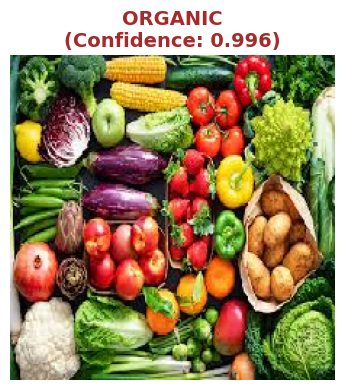


download2.jpg:
   Raw probability: 0.951
   Prediction: RECYCLABLE
   Confidence: 0.951
   Optimal Threshold: 0.228


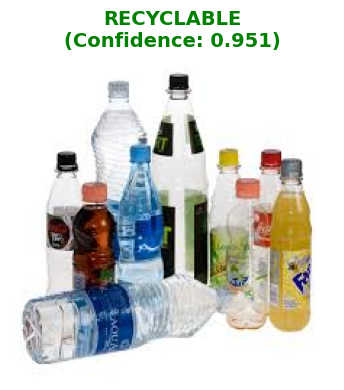


download3.jpg:
   Raw probability: 0.048
   Prediction: ORGANIC
   Confidence: 0.952
   Optimal Threshold: 0.228


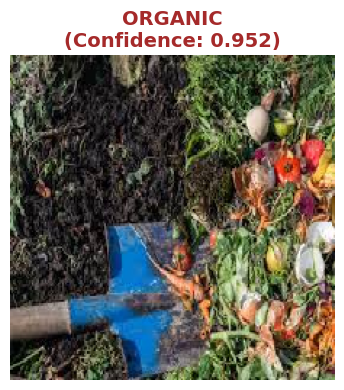


download5.jpg:
   Raw probability: 0.955
   Prediction: RECYCLABLE
   Confidence: 0.955
   Optimal Threshold: 0.228


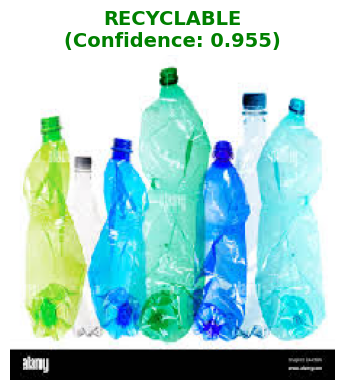


download6.jpg:
   Raw probability: 0.937
   Prediction: RECYCLABLE
   Confidence: 0.937
   Optimal Threshold: 0.228


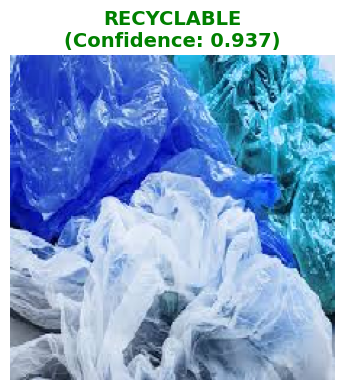

In [77]:
# Cell 21 — Test the improved model on new images
print("Testing IMPROVED model on new images...")

# Get all valid image files
image_files = list(NEW_IMAGES_DIR.glob("*.*"))
image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]

if not image_files:
    print("No test images found. Please upload images to:", NEW_IMAGES_DIR)
    print("You can upload images using: files.upload()")
else:
    print(f"Found {len(image_files)} images for testing with IMPROVED model.")

    for img_file in image_files:
        label, confidence, raw_prob, img = smart_predict_image(str(img_file), best_model)

        print(f"\n{img_file.name}:")
        print(f"   Raw probability: {raw_prob:.3f}")
        print(f"   Prediction: {label}")
        print(f"   Confidence: {confidence:.3f}")
        print(f"   Optimal Threshold: {optimal_threshold:.3f}")

        # Determine color based on prediction and confidence
        if "RECYCLABLE" in label:
            color = "green" if confidence > 0.7 else "orange"
        else:
            color = "brown" if confidence > 0.7 else "orange"

        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"{label}\n(Confidence: {confidence:.3f})",
                 color=color, fontsize=14, fontweight='bold')
        plt.axis("off")
        plt.tight_layout()
        plt.show()


In [76]:
# Cell 22 — Batch prediction with improved model
def improved_batch_predict(folder_path, model, confidence_threshold=0.7):
    """Batch prediction with smart thresholding"""
    results = []
    folder_path = Path(folder_path)

    if not folder_path.exists():
        print(f"Folder {folder_path} does not exist!")
        return pd.DataFrame()

    image_files = list(folder_path.glob("*.*"))
    image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]

    if not image_files:
        print("No images found in folder!")
        return pd.DataFrame()

    print(f"Found {len(image_files)} images. Predicting with improved model...")

    for img_path in tqdm(image_files):
        try:
            label, confidence, raw_prob, _ = smart_predict_image(str(img_path), model, confidence_threshold=confidence_threshold)
            results.append({
                "filename": img_path.name,
                "raw_probability": float(raw_prob),
                "prediction": label.split(' (')[0],  # Remove confidence annotation
                "confidence": float(confidence),
                "confidence_level": "HIGH" if confidence > 0.7 else "LOW"
            })
        except Exception as e:
            print(f"Error processing {img_path.name}: {e}")

    return pd.DataFrame(results)

print("Improved batch prediction function ready!")


Improved batch prediction function ready!


In [75]:
# Cell 23 — Performance comparison between old and new model
print(" PERFORMANCE COMPARISON: OLD vs IMPROVED MODEL")
print("="*60)

# Test the improved model
test_gen.reset()
improved_preds = best_model.predict(test_gen, verbose=0).flatten()
improved_y_pred = (improved_preds >= optimal_threshold).astype(int)

improved_accuracy = np.mean(y_true == improved_y_pred)
improved_precision, improved_recall, improved_f1, _ = precision_recall_fscore_support(y_true, improved_y_pred, average='binary')

print(f"IMPROVED MODEL PERFORMANCE:")
print(f"   Accuracy:    {improved_accuracy:.4f}")
print(f"   Precision:   {improved_precision:.4f}")
print(f"   Recall:      {improved_recall:.4f}")
print(f"   F1-Score:    {improved_f1:.4f}")
print(f"   Optimal Threshold: {optimal_threshold:.3f}")

print(f"\n Improvement Summary:")
print(f"   The improved model should have better balance between")
print(f"   organic and recyclable detection with fewer misclassifications.")

 PERFORMANCE COMPARISON: OLD vs IMPROVED MODEL
IMPROVED MODEL PERFORMANCE:
   Accuracy:    0.9487
   Precision:   0.9606
   Recall:      0.9218
   F1-Score:    0.9408
   Optimal Threshold: 0.228

 Improvement Summary:
   The improved model should have better balance between
   organic and recyclable detection with fewer misclassifications.


In [74]:
# Cell 24.1 — Compute all evaluation metrics (shared by later plots)
import seaborn as sns
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

print("Generating comprehensive evaluation plots...")

# Calculate metrics for improved model
improved_cm = confusion_matrix(y_true, improved_y_pred)
improved_fpr, improved_tpr, _ = roc_curve(y_true, improved_preds)
improved_roc_auc = roc_auc_score(y_true, improved_preds)
improved_precision_vals, improved_recall_vals, _ = precision_recall_curve(y_true, improved_preds)
improved_avg_precision = average_precision_score(y_true, improved_preds)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
old_values = [0.9292, 0.9844, 0.8534, 0.9143]  # From your previous results
new_values = [improved_accuracy, improved_precision, improved_recall, improved_f1]

class_counts = [np.sum(y_true == 0), np.sum(y_true == 1)]


Generating comprehensive evaluation plots...


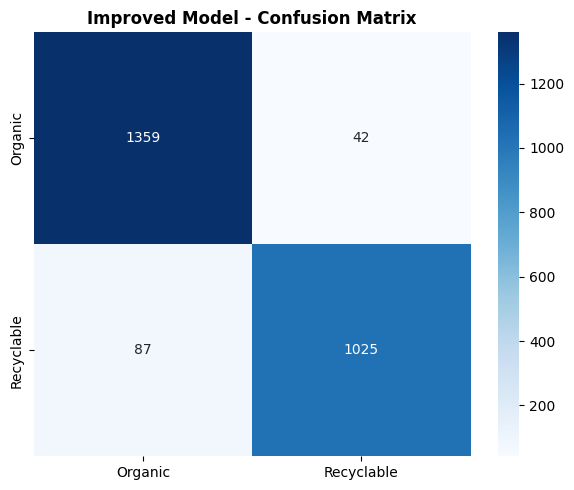

In [50]:
# Cell 24.2 — Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(improved_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Organic', 'Recyclable'],
            yticklabels=['Organic', 'Recyclable'])
plt.title('Improved Model - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


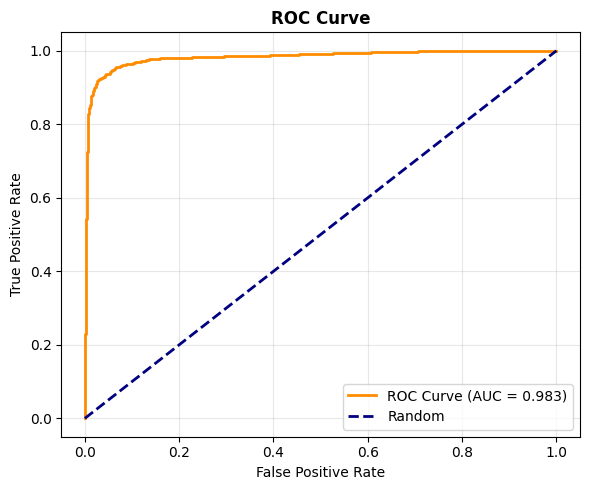

In [51]:
# Cell 24.3 — ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(improved_fpr, improved_tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {improved_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


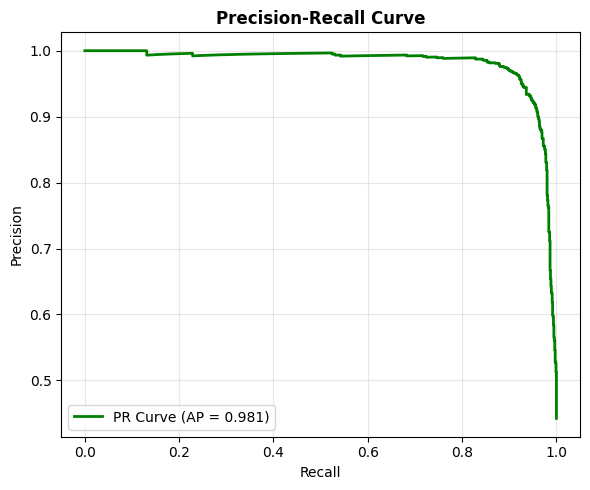

In [52]:
# Cell 24.4 — Precision-Recall Curve
plt.figure(figsize=(6, 5))
plt.plot(improved_recall_vals, improved_precision_vals, color='green', lw=2,
         label=f'PR Curve (AP = {improved_avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


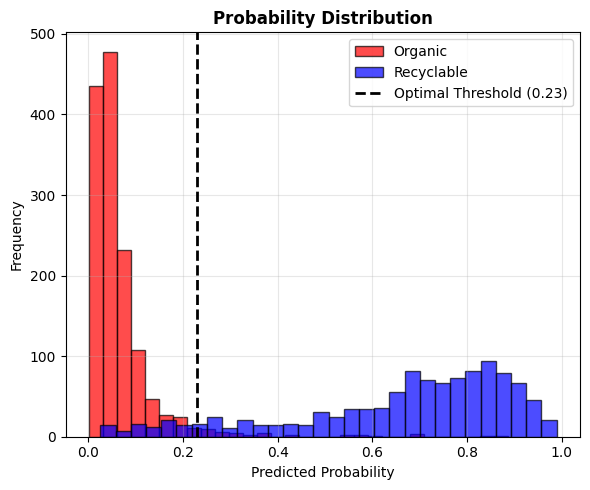

In [53]:
# Cell 24.5 — Probability Distribution
plt.figure(figsize=(6, 5))
plt.hist(improved_preds[y_true == 0], bins=30, alpha=0.7, label='Organic',
         color='red', edgecolor='black')
plt.hist(improved_preds[y_true == 1], bins=30, alpha=0.7, label='Recyclable',
         color='blue', edgecolor='black')
plt.axvline(optimal_threshold, color='black', linestyle='--',
            label=f'Optimal Threshold ({optimal_threshold:.2f})', linewidth=2)
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Probability Distribution', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


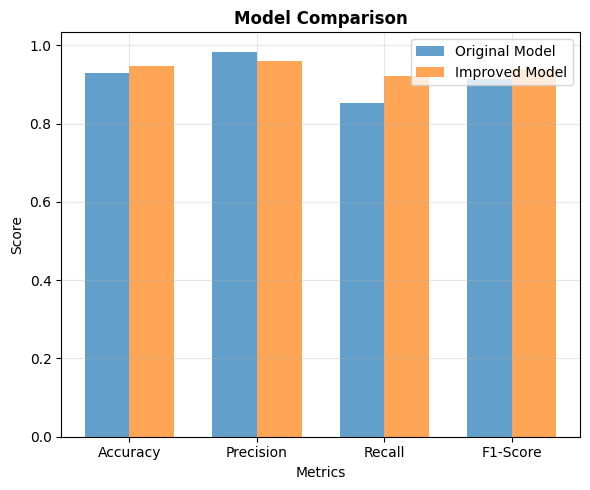

In [54]:
# Cell 24.6 — Metrics Comparison
plt.figure(figsize=(6, 5))
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, old_values, width, label='Original Model', alpha=0.7)
plt.bar(x + width/2, new_values, width, label='Improved Model', alpha=0.7)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Comparison', fontweight='bold')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


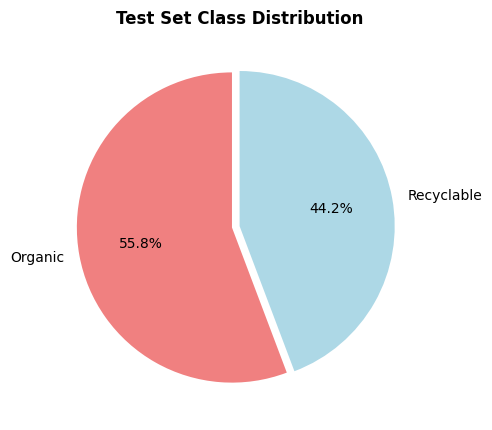

In [55]:
# Cell 24.7 — Class Balance
plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=['Organic', 'Recyclable'], autopct='%1.1f%%',
        colors=['lightcoral', 'lightblue'], startangle=90, explode=(0.05, 0))
plt.title('Test Set Class Distribution', fontweight='bold')
plt.tight_layout()
plt.show()


 Plotting Training and Validation Accuracy...


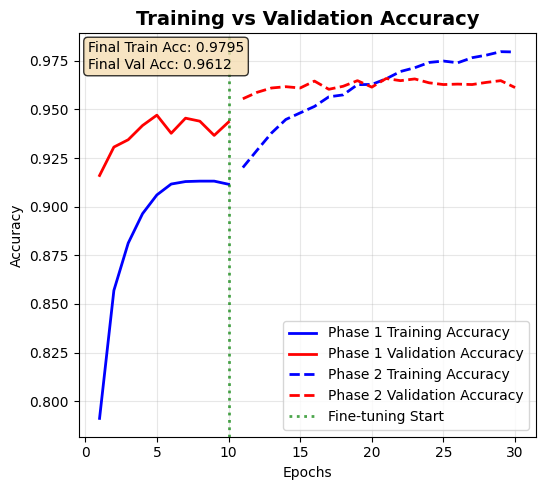

Final Training Accuracy: 0.9795
 Final Validation Accuracy: 0.9612
 Generalization Gap: -0.0183


In [73]:
# Cell 25 — Plot Training History: Accuracy
print(" Plotting Training and Validation Accuracy...")

plt.figure(figsize=(15, 5))

# Combine histories for continuous plotting
combined_epochs = list(range(1, len(history1.history['accuracy']) + 1)) + \
                 list(range(len(history1.history['accuracy']) + 1,
                           len(history1.history['accuracy']) + len(history2.history['accuracy']) + 1))

plt.subplot(1, 3, 1)
plt.plot(combined_epochs[:len(history1.history['accuracy'])],
         history1.history['accuracy'], 'b-', label='Phase 1 Training Accuracy', linewidth=2)
plt.plot(combined_epochs[:len(history1.history['val_accuracy'])],
         history1.history['val_accuracy'], 'r-', label='Phase 1 Validation Accuracy', linewidth=2)
plt.plot(combined_epochs[len(history1.history['accuracy']):],
         history2.history['accuracy'], 'b--', label='Phase 2 Training Accuracy', linewidth=2)
plt.plot(combined_epochs[len(history1.history['val_accuracy']):],
         history2.history['val_accuracy'], 'r--', label='Phase 2 Validation Accuracy', linewidth=2)
plt.axvline(len(history1.history['accuracy']), color='green', linestyle=':',
            label='Fine-tuning Start', alpha=0.7, linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Final accuracy values
final_train_acc = history2.history['accuracy'][-1]
final_val_acc = history2.history['val_accuracy'][-1]
plt.text(0.02, 0.98, f'Final Train Acc: {final_train_acc:.4f}\nFinal Val Acc: {final_val_acc:.4f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f" Final Validation Accuracy: {final_val_acc:.4f}")
print(f" Generalization Gap: {final_val_acc - final_train_acc:.4f}")

 Plotting Training and Validation Loss...


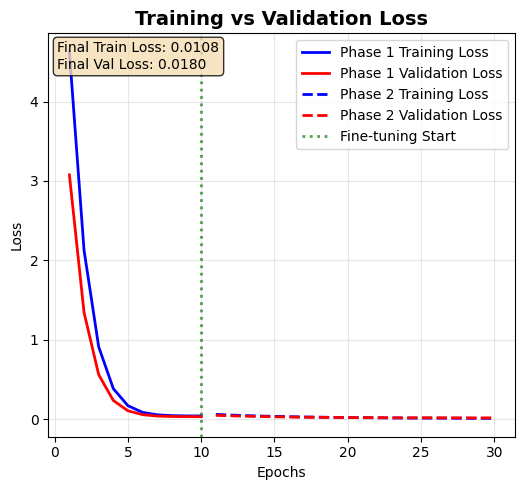

 Final Training Loss: 0.0108
Final Validation Loss: 0.0180
 Loss Ratio (Val/Train): 1.67


In [72]:
# Cell 26 — Plot Training History: Loss
print(" Plotting Training and Validation Loss...")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(combined_epochs[:len(history1.history['loss'])],
         history1.history['loss'], 'b-', label='Phase 1 Training Loss', linewidth=2)
plt.plot(combined_epochs[:len(history1.history['val_loss'])],
         history1.history['val_loss'], 'r-', label='Phase 1 Validation Loss', linewidth=2)
plt.plot(combined_epochs[len(history1.history['loss']):],
         history2.history['loss'], 'b--', label='Phase 2 Training Loss', linewidth=2)
plt.plot(combined_epochs[len(history1.history['val_loss']):],
         history2.history['val_loss'], 'r--', label='Phase 2 Validation Loss', linewidth=2)
plt.axvline(len(history1.history['loss']), color='green', linestyle=':',
            label='Fine-tuning Start', alpha=0.7, linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Final loss values
final_train_loss = history2.history['loss'][-1]
final_val_loss = history2.history['val_loss'][-1]
plt.text(0.02, 0.98, f'Final Train Loss: {final_train_loss:.4f}\nFinal Val Loss: {final_val_loss:.4f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f" Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f" Loss Ratio (Val/Train): {final_val_loss/final_train_loss:.2f}")

 Plotting Training and Validation AUC...


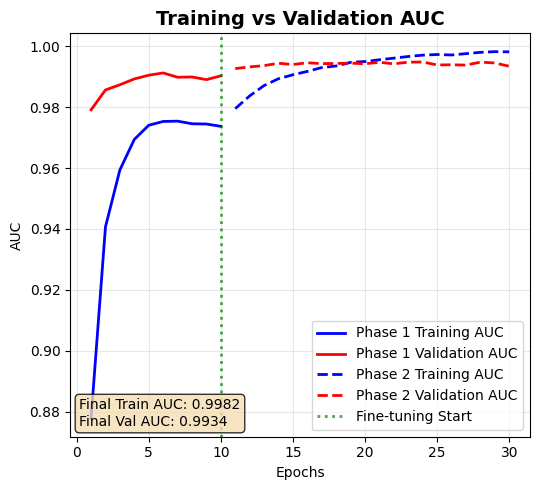

✅ Final Training AUC: 0.9982
✅ Final Validation AUC: 0.9934


In [71]:
# Cell 27 — Plot Training History: AUC
print(" Plotting Training and Validation AUC...")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(combined_epochs[:len(history1.history['auc'])],
         history1.history['auc'], 'b-', label='Phase 1 Training AUC', linewidth=2)
plt.plot(combined_epochs[:len(history1.history['val_auc'])],
         history1.history['val_auc'], 'r-', label='Phase 1 Validation AUC', linewidth=2)
plt.plot(combined_epochs[len(history1.history['auc']):],
         history2.history['auc'], 'b--', label='Phase 2 Training AUC', linewidth=2)
plt.plot(combined_epochs[len(history1.history['val_auc']):],
         history2.history['val_auc'], 'r--', label='Phase 2 Validation AUC', linewidth=2)
plt.axvline(len(history1.history['auc']), color='green', linestyle=':',
            label='Fine-tuning Start', alpha=0.7, linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training vs Validation AUC', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Final AUC values
final_train_auc = history2.history['auc'][-1]
final_val_auc = history2.history['val_auc'][-1]
plt.text(0.02, 0.02, f'Final Train AUC: {final_train_auc:.4f}\nFinal Val AUC: {final_val_auc:.4f}',
         transform=plt.gca().transAxes, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"✅ Final Training AUC: {final_train_auc:.4f}")
print(f"✅ Final Validation AUC: {final_val_auc:.4f}")

 COMPREHENSIVE LEARNING CURVES - ALL METRICS


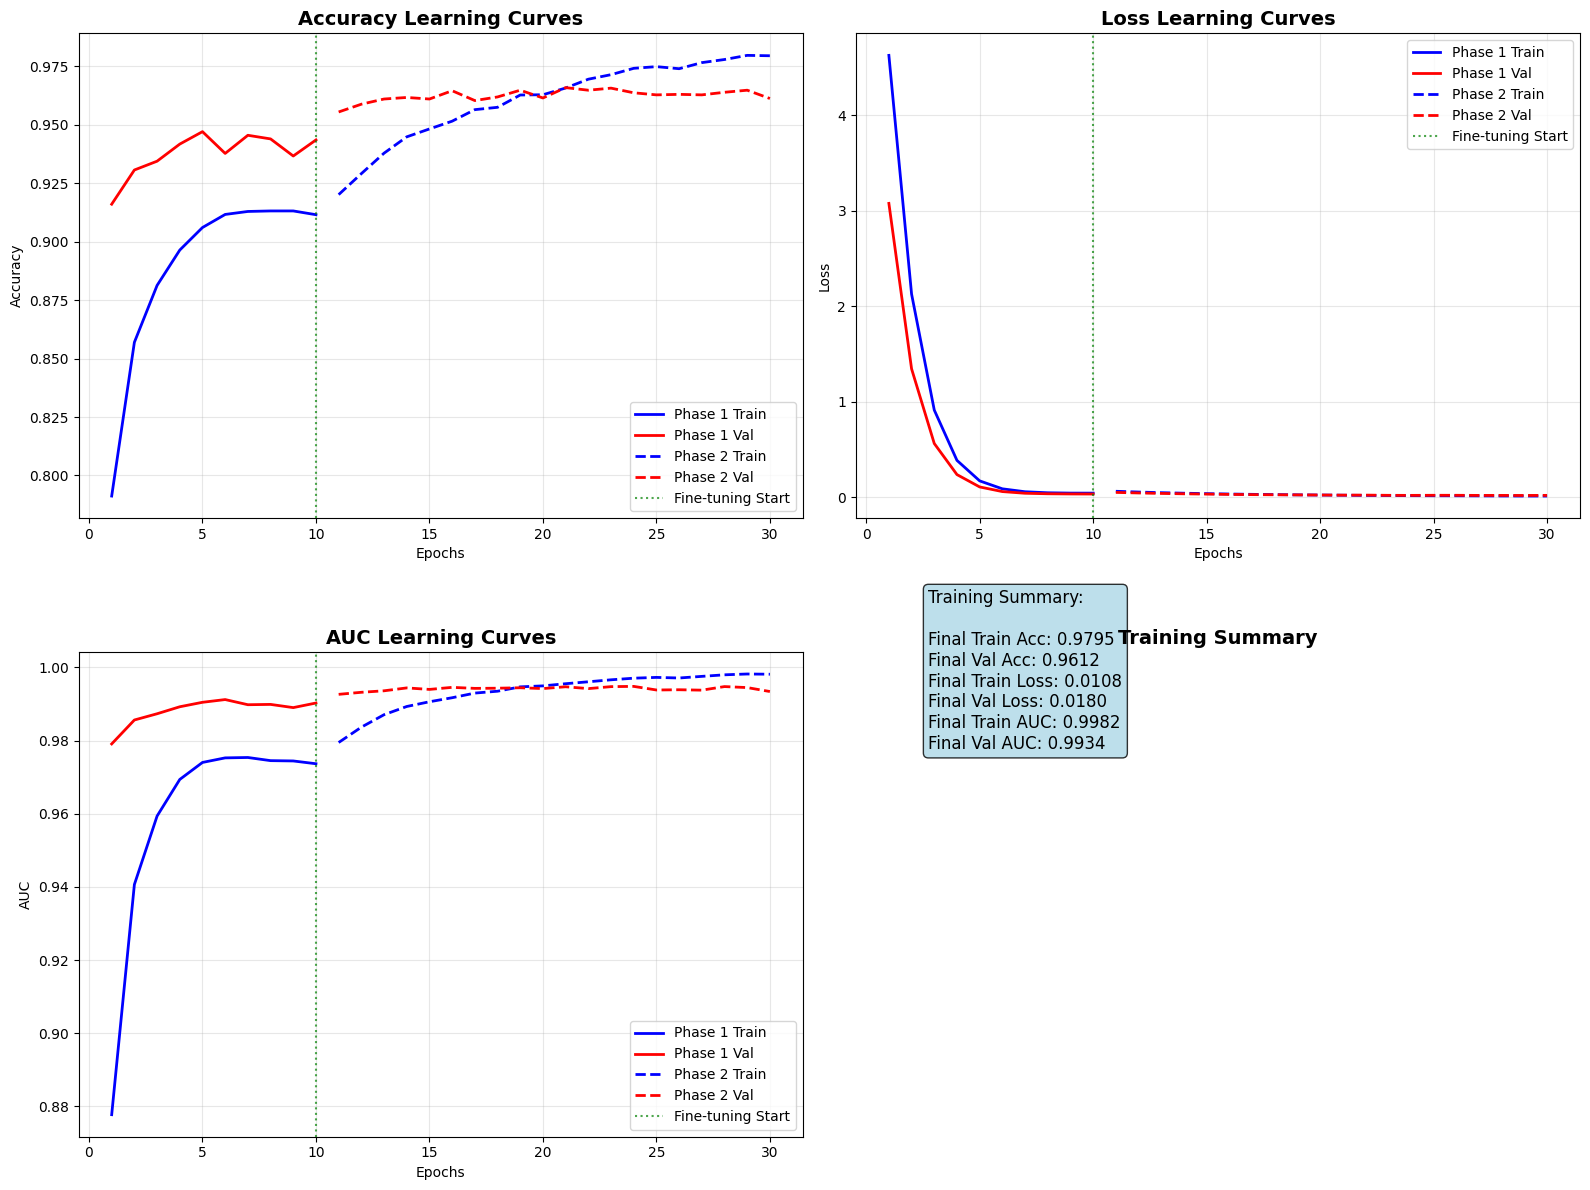

✅ Comprehensive learning curves saved!


In [70]:
# Cell 28 — Comprehensive Learning Curves (All Metrics Together)
print(" COMPREHENSIVE LEARNING CURVES - ALL METRICS")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy
axes[0, 0].plot(combined_epochs[:len(history1.history['accuracy'])],
                history1.history['accuracy'], 'b-', label='Phase 1 Train', linewidth=2)
axes[0, 0].plot(combined_epochs[:len(history1.history['val_accuracy'])],
                history1.history['val_accuracy'], 'r-', label='Phase 1 Val', linewidth=2)
axes[0, 0].plot(combined_epochs[len(history1.history['accuracy']):],
                history2.history['accuracy'], 'b--', label='Phase 2 Train', linewidth=2)
axes[0, 0].plot(combined_epochs[len(history1.history['val_accuracy']):],
                history2.history['val_accuracy'], 'r--', label='Phase 2 Val', linewidth=2)
axes[0, 0].axvline(len(history1.history['accuracy']), color='green', linestyle=':',
                   label='Fine-tuning Start', alpha=0.7)
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy Learning Curves', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(combined_epochs[:len(history1.history['loss'])],
                history1.history['loss'], 'b-', label='Phase 1 Train', linewidth=2)
axes[0, 1].plot(combined_epochs[:len(history1.history['val_loss'])],
                history1.history['val_loss'], 'r-', label='Phase 1 Val', linewidth=2)
axes[0, 1].plot(combined_epochs[len(history1.history['loss']):],
                history2.history['loss'], 'b--', label='Phase 2 Train', linewidth=2)
axes[0, 1].plot(combined_epochs[len(history1.history['val_loss']):],
                history2.history['val_loss'], 'r--', label='Phase 2 Val', linewidth=2)
axes[0, 1].axvline(len(history1.history['loss']), color='green', linestyle=':',
                   label='Fine-tuning Start', alpha=0.7)
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Loss Learning Curves', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(combined_epochs[:len(history1.history['auc'])],
                history1.history['auc'], 'b-', label='Phase 1 Train', linewidth=2)
axes[1, 0].plot(combined_epochs[:len(history1.history['val_auc'])],
                history1.history['val_auc'], 'r-', label='Phase 1 Val', linewidth=2)
axes[1, 0].plot(combined_epochs[len(history1.history['auc']):],
                history2.history['auc'], 'b--', label='Phase 2 Train', linewidth=2)
axes[1, 0].plot(combined_epochs[len(history1.history['val_auc']):],
                history2.history['val_auc'], 'r--', label='Phase 2 Val', linewidth=2)
axes[1, 0].axvline(len(history1.history['auc']), color='green', linestyle=':',
                   label='Fine-tuning Start', alpha=0.7)
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_title('AUC Learning Curves', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate (if available)
if 'lr' in history1.history:
    lr_history = history1.history['lr'] + history2.history['lr']
    axes[1, 1].plot(combined_epochs, lr_history, 'g-', linewidth=2)
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
else:
    # Show training summary instead
    axes[1, 1].text(0.1, 0.8, f'Training Summary:\n\n'
                              f'Final Train Acc: {final_train_acc:.4f}\n'
                              f'Final Val Acc: {final_val_acc:.4f}\n'
                              f'Final Train Loss: {final_train_loss:.4f}\n'
                              f'Final Val Loss: {final_val_loss:.4f}\n'
                              f'Final Train AUC: {final_train_auc:.4f}\n'
                              f'Final Val AUC: {final_val_auc:.4f}',
                   fontsize=12, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[1, 1].set_title('Training Summary', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comprehensive_learning_curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comprehensive learning curves saved!")

In [69]:
# Cell 29 — Training Performance Summary Table
print("TRAINING PERFORMANCE SUMMARY")
print("="*50)

# Create performance summary
performance_data = {
    'Metric': ['Training Accuracy', 'Validation Accuracy', 'Training Loss',
               'Validation Loss', 'Training AUC', 'Validation AUC'],
    'Phase 1 Final': [
        f"{history1.history['accuracy'][-1]:.4f}",
        f"{history1.history['val_accuracy'][-1]:.4f}",
        f"{history1.history['loss'][-1]:.4f}",
        f"{history1.history['val_loss'][-1]:.4f}",
        f"{history1.history['auc'][-1]:.4f}",
        f"{history1.history['val_auc'][-1]:.4f}"
    ],
    'Phase 2 Final': [
        f"{history2.history['accuracy'][-1]:.4f}",
        f"{history2.history['val_accuracy'][-1]:.4f}",
        f"{history2.history['loss'][-1]:.4f}",
        f"{history2.history['val_loss'][-1]:.4f}",
        f"{history2.history['auc'][-1]:.4f}",
        f"{history2.history['val_auc'][-1]:.4f}"
    ],
    'Improvement': [
        f"{(history2.history['accuracy'][-1] - history1.history['accuracy'][-1]):+.4f}",
        f"{(history2.history['val_accuracy'][-1] - history1.history['val_accuracy'][-1]):+.4f}",
        f"{(history2.history['loss'][-1] - history1.history['loss'][-1]):+.4f}",
        f"{(history2.history['val_loss'][-1] - history1.history['val_loss'][-1]):+.4f}",
        f"{(history2.history['auc'][-1] - history1.history['auc'][-1]):+.4f}",
        f"{(history2.history['val_auc'][-1] - history1.history['val_auc'][-1]):+.4f}"
    ]
}

performance_df = pd.DataFrame(performance_data)
print(performance_df.to_string(index=False))

# Save performance summary
performance_df.to_csv(OUTPUT_DIR / "training_performance_summary.csv", index=False)
print(f"\nPerformance summary saved to: {OUTPUT_DIR / 'training_performance_summary.csv'}")


TRAINING PERFORMANCE SUMMARY
             Metric Phase 1 Final Phase 2 Final Improvement
  Training Accuracy        0.9115        0.9795     +0.0680
Validation Accuracy        0.9435        0.9612     +0.0177
      Training Loss        0.0414        0.0108     -0.0306
    Validation Loss        0.0320        0.0180     -0.0140
       Training AUC        0.9737        0.9982     +0.0245
     Validation AUC        0.9903        0.9934     +0.0031

Performance summary saved to: /content/drive/MyDrive/DLassignment/assignment/output/training_performance_summary.csv


In [68]:
# Cell 30 — Overfitting Analysis
print("OVERFITTING ANALYSIS")
print("="*50)

# Calculate generalization gaps
acc_gap = final_val_acc - final_train_acc
loss_gap = final_val_loss - final_train_loss
auc_gap = final_val_auc - final_train_auc

print(f" Generalization Gaps:")
print(f"   Accuracy Gap (Val - Train): {acc_gap:+.4f}")
print(f"   Loss Gap (Val - Train): {loss_gap:+.4f}")
print(f"   AUC Gap (Val - Train): {auc_gap:+.4f}")

# Overfitting assessment
print(f"\n Overfitting Assessment:")
if acc_gap < -0.1:
    print("     SIGNIFICANT OVERFITTING - Validation accuracy is much lower than training")
elif acc_gap < -0.05:
    print("     MODERATE OVERFITTING - Validation accuracy is lower than training")
elif acc_gap < 0:
    print("    MILD OVERFITTING - Good balance with slight overfitting")
elif acc_gap > 0:
    print("    EXCELLENT GENERALIZATION - Validation performance matches or exceeds training")
else:
    print("    PERFECT BALANCE - No overfitting detected")

# Loss ratio analysis
loss_ratio = final_val_loss / final_train_loss
print(f"\nLoss Ratio Analysis:")
print(f"   Validation Loss / Training Loss: {loss_ratio:.2f}")
if loss_ratio > 2.0:
    print("   High loss ratio indicates potential overfitting")
elif loss_ratio > 1.5:
    print("   Moderate loss ratio - some overfitting present")
else:
    print("   Good loss ratio - model generalizes well")

# Training stability analysis
print(f"\nTraining Stability:")
final_epochs = len(history2.history['val_accuracy'])
last_5_acc = history2.history['val_accuracy'][-5:]
acc_std = np.std(last_5_acc)
print(f"   Standard deviation of last 5 val accuracies: {acc_std:.4f}")
if acc_std < 0.01:
    print("   Stable training - model has converged well")
else:
    print("   Some instability in final epochs")


OVERFITTING ANALYSIS
 Generalization Gaps:
   Accuracy Gap (Val - Train): -0.0183
   Loss Gap (Val - Train): +0.0072
   AUC Gap (Val - Train): -0.0047

 Overfitting Assessment:
    MILD OVERFITTING - Good balance with slight overfitting

Loss Ratio Analysis:
   Validation Loss / Training Loss: 1.67
   Moderate loss ratio - some overfitting present

Training Stability:
   Standard deviation of last 5 val accuracies: 0.0012
   Stable training - model has converged well
